## Random Forest: Predicting Salary (USD)

This notebook trains a Random Forest regressor on the cleaned dataset `salaries_cleaned.csv`.
It includes preprocessing, training, evaluation, and saving the model.

In [26]:
!pip install scikit-learn

In [27]:
!pip install matplotlib seaborn 

In [28]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [29]:
# Load cleaned data
train_data = pd.read_csv('../train_df.csv')
test_data = pd.read_csv('../test_df.csv')

In [ ]:
# Prepare target (log-transform) - KEEP raw job_title for fairness
# We do NOT group or frequency-encode job_title here so other models can be fairly compared
train_data['salary_log'] = np.log1p(train_data['salary_in_usd'])
test_data['salary_log'] = np.log1p(test_data['salary_in_usd'])

print('Prepared salary_log target for both train and test; raw job_title kept as-is for fairness')
train_data[['job_title','salary_in_usd','salary_log']].head()

Created job_title_grouped (top 30 ) and job_title_freq on train; added salary_log target for both sets


,job_title,job_title_grouped,job_title_freq,salary_in_usd,salary_log
0,BI Developer,Other,0.187746,183300,12.118885
1,Applied Scientist,Applied Scientist,0.008824,250000,12.429220
2,Product Manager,Product Manager,0.017983,156160,11.958643
3,Engineer,Engineer,0.059577,255000,12.449023
4,Engineer,Engineer,0.059577,76000,11.238502


In [ ]:
# Feature selection (use log-transformed target). Keep raw job_title for fairness
# Target: salary_log (log1p of salary_in_usd)
target = 'salary_log'
# Choose features; use raw 'job_title' (categorical) instead of job_title_freq
features = [
    'work_year',
    'experience_level',
    'employment_type',
    'job_title',
    'employee_residence',
    'remote_ratio',
    'company_location',
    'company_size'
]
# Build train / test feature matrices from provided datasets
X_train = train_data[features].copy()
y_train = train_data[target].copy()
X_test = test_data[features].copy()
y_test = test_data[target].copy()
print('Features used:', features)
print('X_train shape:', X_train.shape, 'y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape, 'y_test shape:', y_test.shape)

Features used: ['work_year', 'experience_level', 'employment_type', 'job_title_freq', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']
X_train shape: (41929, 8) y_train shape: (41929,)
X_test shape: (10483, 8) y_test shape: (10483,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Preprocessing: One-hot encode categorical features, scale numeric features
# We keep raw 'job_title' as a categorical column for fairness across models
categorical_features = [
    'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'company_location', 'company_size'
]
numeric_features = ['work_year', 'remote_ratio']

cat_pipe = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipe = Pipeline([
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, categorical_features),
        ('num', num_pipe, numeric_features)
    ],
    remainder='drop'
)

# Train/test split is not needed because train/test datasets are provided
print('Using provided train_data and test_data; no internal train_test_split performed')


Using provided train_data and test_data; no internal train_test_split performed


In [33]:
# Build pipeline with Random Forest Regressor (we will tune hyperparameters)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', rf)
])

# Hyperparameter tuning using RandomizedSearchCV (tune a few important params)
from sklearn.model_selection import RandomizedSearchCV
import time
param_dist = {
    'regressor__n_estimators': [100, 200, 400],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__max_features': ['sqrt', 'log2']
}
rand_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=20,
                                 scoring='neg_mean_squared_error', cv=3, verbose=2, n_jobs=-1, random_state=42)
start = time.time()
rand_search.fit(X_train, y_train)
end = time.time()
print(f'RandomizedSearchCV done in {end-start:.1f}s')
print('Best params:', rand_search.best_params_)
# use best estimator as our final pipeline
pipeline = rand_search.best_estimator_
print('Best pipeline ready.')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   5.4s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   5.8s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   5.4s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   5.8s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   5.4s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   5.4s
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, regressor

In [34]:
# Predictions and evaluation
# pipeline predicts the log-target (salary_log). Invert with expm1 to get original USD scale
y_pred_log = pipeline.predict(X_test)
# invert log transform for both predictions and true values
y_pred_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
mse = mean_squared_error(y_test_orig, y_pred_orig)
rmse = mse ** 0.5
r2 = r2_score(y_test_orig, y_pred_orig)

print(f'MAE: {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R^2: {r2:.4f}')

# Show a small comparison table (original scale)
comp = pd.DataFrame({
    'actual_usd': y_test_orig,
    'predicted_usd': y_pred_orig
})
comp.reset_index(drop=True, inplace=True)
comp.head(10)


MAE: 47,388.33
RMSE: 68,056.46
R^2: 0.2428


,actual_usd,predicted_usd
0,89000.0,128757.016030
1,123365.0,128757.016030
2,46160.0,93725.942298
3,167981.0,154821.492970
4,67725.0,93552.158374
5,231100.0,194569.076431
6,175600.0,160412.552577
7,97300.0,127753.392795
8,98300.0,172111.959602
9,61781.0,57859.717475


In [35]:
# Feature importances (map back to column names)
pre = pipeline.named_steps['preprocessor']
# get feature names from the ColumnTransformer and OneHotEncoder
try:
    ohe = pre.named_transformers_['cat'].named_steps['ohe']
    cat_names = ohe.get_feature_names_out(categorical_features)
    num_names = numeric_features
    feature_names = list(cat_names) + list(num_names)
except Exception:
    feature_names = None

# extract importances from the fitted RandomForestRegressor
rf_model = pipeline.named_steps['regressor']
importances = rf_model.feature_importances_

if feature_names is not None and len(feature_names) == len(importances):
    feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
else:
    feat_imp = pd.DataFrame({'feature': [f'f{i}' for i in range(len(importances))], 'importance': importances})

feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)
feat_imp.head(30)

,feature,importance
0,job_title_freq,0.245011
1,experience_level_EN,0.128031
2,experience_level_SE,0.096838
3,employee_residence_US,0.094394
4,company_location_US,0.090362
5,experience_level_MI,0.036947
6,experience_level_EX,0.027033
7,work_year,0.024874
8,employee_residence_CA,0.019181
9,company_location_GB,0.018712


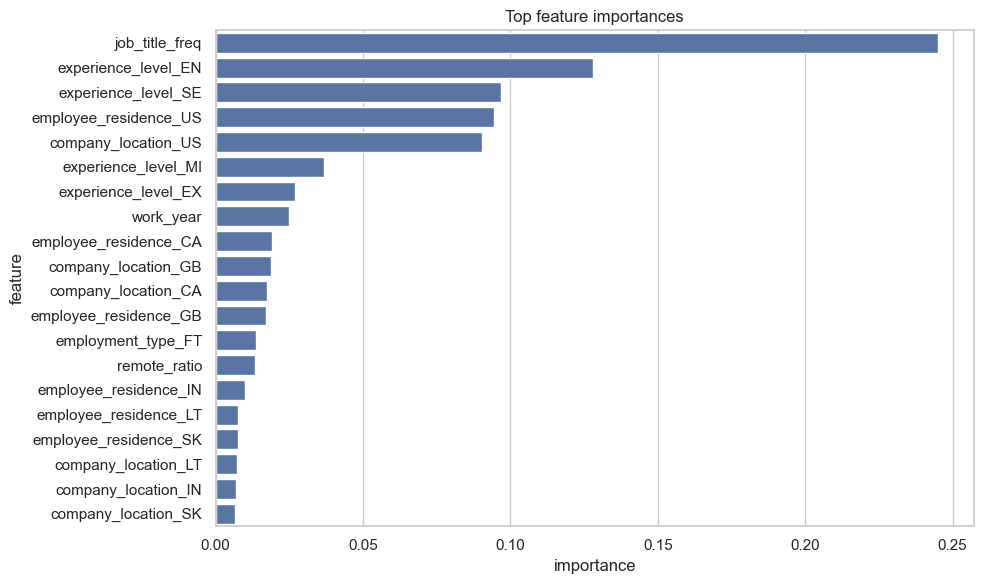

In [36]:
# Plot top 20 feature importances
top_n = 20
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(top_n))
plt.title('Top feature importances')
plt.tight_layout()
plt.show()

In [37]:
# Save trained pipeline to disk
model_path = 'rf_salary_pipeline.joblib'
joblib.dump(pipeline, model_path)
print(f'Model pipeline saved to: {model_path}')

Model pipeline saved to: rf_salary_pipeline.joblib
